# Chapter 2: J-holomorphic Curves

**Source orientation.** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 2, printed pp. 17-38; PDF pp. 32-53. This notebook uses the local PDF only as an orientation map; the prose, code, diagrams, and checks below are original.

**Chapter question.** What does the equation `dbar_J(u)=0` force before transversality and compactness enter?

The chapter starts with pointwise linear algebra and ends with a topological inequality. The computational thread here follows that path: build an almost complex structure, measure the local Cauchy-Riemann residual, watch why high-order agreement is rigid, separate critical points from multiple covers, and finish with the adjunction ledger that constrains singularities in real dimension four.


## Source Coverage

| Section | Standalone coverage in this notebook | Visual or check |
| --- | --- | --- |
| 2.1 Almost complex structures | Tame and compatible structures, the metric produced by a symplectic form and `J`, and the role of `J^2=-I`. | `almost-complex-taming-metric.png`; symbolic `J^2+I` and taming positivity checks. |
| 2.2 Nonlinear Cauchy-Riemann equations | The section `dbar_J`, its local coordinate form, the residual interpretation, and the energy-area identity for compatible targets. | `cauchy-riemann-residual-heatmap.png`; residual ratio and energy/area JSON. |
| 2.3 Unique continuation | Vanishing to infinite order, Aronszajn/Carleman scaffolding, and why a solution cannot split after infinite-order contact. | `vanishing-order-tracker.png`; fitted order checks for finite holomorphic contacts. |
| 2.4 Critical points | Isolated critical points, local coordinates at regular points, and local factorization through a regular branch. | `critical-points-and-multiple-covers.png`; derivative-zero and fiber-count checks. |
| 2.5 Somewhere injective curves | Simple versus multiply covered curves, injective points, countable noninjective set, and branched-cover factorization. | Multiple-cover degree check and simple graph injectivity check. |
| 2.6 Adjunction inequality | Positivity of intersections in four dimensions, self-intersection counts, and the CP2 degree-genus ledger. | `adjunction-defect-ledger.png`; exact adjunction defect checks. |

The coverage JSON written by the setup cell is a machine-readable promise that every source section has a notebook object and a validation target.


## Library Routing

| Concept | Representation | Library | Why this route fits |
| --- | --- | --- | --- |
| Tame almost complex structure | Matrix family, metric ellipse, area heatmap | SymPy + NumPy + Matplotlib | The concept is pointwise linear algebra; exact symbolic identities and a planar metric picture expose the geometry directly. |
| Local `dbar_J` residual | Finite-difference residual heatmap | NumPy + Matplotlib | The residual is a scalar field over the domain; a heatmap makes the anti-holomorphic error inspectable. |
| Unique continuation scaffold | Log-log vanishing-order tracker | NumPy + Matplotlib | Finite order contact has measurable slopes; the plot prepares the infinite-order theorem without copying the analytic proof. |
| Critical points and covers | Branch derivative heatmap and fiber markers | NumPy + Matplotlib | The local model `z -> z^m` shows both an isolated critical point and generic multiplicity. |
| Proof structure | Directed dependency graph | NetworkX + Matplotlib | The chapter's analytic statements feed later geometric statements; a DAG prevents those dependencies from blurring. |
| Adjunction | Exact integer ledger and bar plot | Python arithmetic + Matplotlib | The inequality is topological and discrete in the CP2 model, so exact rows plus a compact visual are the right scale. |
| Sanity checks | JSON summaries and artifact assertions | stdlib JSON + course helpers | Durable checks catch stale visuals, broken paths, and decorative artifacts with no invariant behind them. |


## Visualization Storyboard

1. `almost-complex-taming-metric.png` makes the pointwise conditions `J^2=-I` and `omega(v,Jv)>0` visible before any PDE appears.
2. `cauchy-riemann-residual-heatmap.png` preserves the residual heatmap role: holomorphic data stays dark, a conjugate perturbation lights up.
3. `vanishing-order-tracker.png` gives a finite-order scaffold for unique continuation and the Carleman similarity discussion.
4. `critical-points-and-multiple-covers.png` ties isolated critical behavior to the branch-cover model `z -> z^2` and the somewhere-injective distinction.
5. `proof-dependency-map.png` preserves and expands the proof map from local elliptic facts to adjunction.
6. `adjunction-defect-ledger.png` turns the four-dimensional adjunction inequality into exact CP2 bookkeeping.

The setup cell serializes this same sequence to `visual-storyboard.json` for QC.


In [1]:
from pathlib import Path
import csv
import json
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        candidate = base if base.name == "J-Holomorphic-Curves-and-Symplectic-Topology" else base / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate JHCST book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_dir, assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-02"
FIG_DIR = artifact_dir(UNIT, "figures")
CHECK_DIR = artifact_dir(UNIT, "checks")
TABLE_DIR = artifact_dir(UNIT, "tables")
HTML_DIR = artifact_dir(UNIT, "html")

coverage = [
    {"section": "2.1", "topic": "almost complex structures; tame and compatible metrics", "notebook_object": "almost-complex-taming-metric.png", "check": "symbolic J^2=-I and positive omega(v,Jv) samples"},
    {"section": "2.2", "topic": "nonlinear Cauchy-Riemann equation and energy identity", "notebook_object": "cauchy-riemann-residual-heatmap.png", "check": "dbar residual ratio and energy-area relative error"},
    {"section": "2.3", "topic": "unique continuation via infinite-order contact", "notebook_object": "vanishing-order-tracker.png", "check": "finite vanishing orders recover their slopes"},
    {"section": "2.4", "topic": "critical points and local regular-branch factorization", "notebook_object": "critical-points-and-multiple-covers.png", "check": "branch derivative has one zero and generic fiber has two points"},
    {"section": "2.5", "topic": "simple, somewhere injective, and multiply covered curves", "notebook_object": "critical-points-and-multiple-covers.png", "check": "simple graph has one preimage while cover factors through z^2"},
    {"section": "2.6", "topic": "positivity of intersections and adjunction inequality", "notebook_object": "adjunction-defect-ledger.png", "check": "CP2 examples have nonnegative adjunction defect"},
]
source_coverage_path = save_json(
    {"unit": UNIT, "source_span": "printed pp. 17-38; PDF pp. 32-53", "sections": coverage, "passed": all(row["check"] for row in coverage)},
    UNIT,
    "checks",
    "source-coverage.json",
)

storyboard = [
    {"visual": "almost-complex-taming-metric.png", "concept": "J is a pointwise square root of -I that turns symplectic area into a metric", "inspection_target": "positive area values and the metric ellipse", "validation": "J^2=-I, compatibility defect zero, positive sampled taming"},
    {"visual": "cauchy-riemann-residual-heatmap.png", "concept": "dbar_J is the local error signal for being a J-curve", "inspection_target": "dark holomorphic panel versus bright conjugate perturbation", "validation": "perturbed residual is much larger than holomorphic residual"},
    {"visual": "vanishing-order-tracker.png", "concept": "finite order contacts have finite slopes; infinite-order contact is rigid", "inspection_target": "log-log slopes for z^m", "validation": "fitted slopes equal the declared orders"},
    {"visual": "critical-points-and-multiple-covers.png", "concept": "z^2 has an isolated critical point and generic two-point fibers", "inspection_target": "derivative heatmap and paired preimages", "validation": "fiber count and branch zero count"},
    {"visual": "proof-dependency-map.png", "concept": "local elliptic facts feed simple-curve structure and adjunction", "inspection_target": "directed path from dbar equation to adjunction", "validation": "directed acyclic graph with required terminal nodes"},
    {"visual": "adjunction-defect-ledger.png", "concept": "genus and double points are bounded by class data in CP2", "inspection_target": "defect bars and equality examples", "validation": "all integer examples satisfy the inequality"},
]
visual_storyboard_path = save_json({"unit": UNIT, "storyboard": storyboard, "passed": len(storyboard) >= 5}, UNIT, "checks", "visual-storyboard.json")

source_coverage_path, visual_storyboard_path


(WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-02/checks/source-coverage.json'),
 WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-02/checks/visual-storyboard.json'))

## Almost Complex Structures as Linear Algebra

At one tangent space, an almost complex structure is a real linear map whose square is `-I`. A symplectic form tames it when every nonzero vector and its `J`-rotation enclose positive symplectic area. The two-dimensional family below is useful because every entry is visible and the positivity can be checked exactly:

`J_a = [[a, -(1+a^2)], [1, -a]]`.

For the standard area form, `omega(v,J_a v)` is a positive quadratic form. The figure shows both the area signal and the metric ellipse that `omega(.,J_a .)` produces.


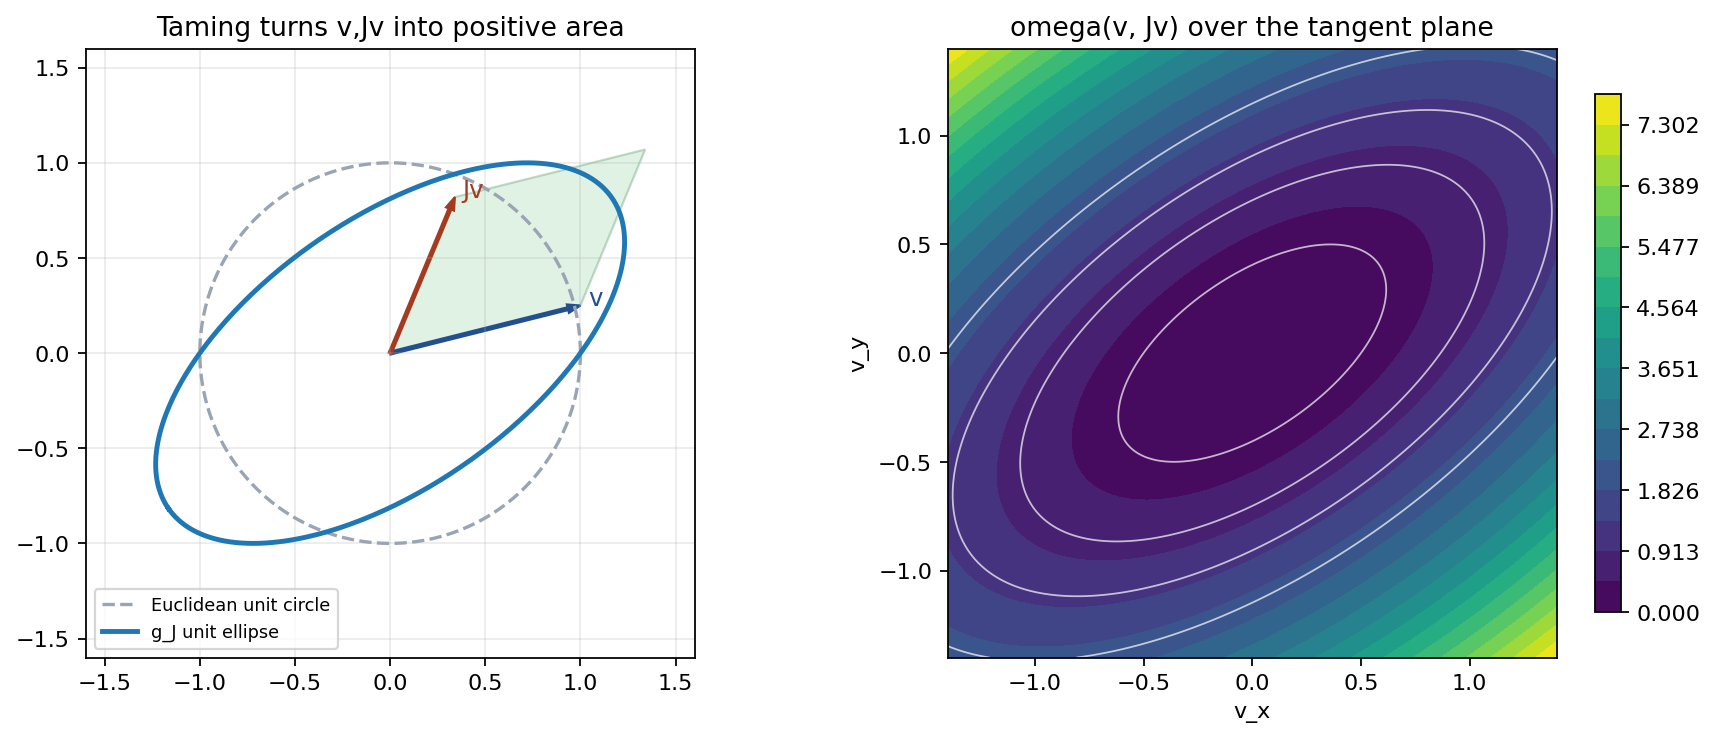

{'a': 0.72,
 'symbolic_J_squared_plus_I_is_zero': True,
 'symbolic_metric_determinant': '1',
 'numeric_J_squared_plus_I_norm': 5.822187176818261e-17,
 'compatibility_defect_norm': 5.822187176818261e-17,
 'metric_eigenvalues': [0.49396497727822214, 2.0244350227217778],
 'minimum_taming_on_unit_circle': 0.4939662322423819,
 'passed': True}

In [2]:
a_value = 0.72
J = np.array([[a_value, -(1.0 + a_value**2)], [1.0, -a_value]])
Omega = np.array([[0.0, 1.0], [-1.0, 0.0]])
metric = Omega @ J

s = sp.symbols("a", real=True)
J_sym = sp.Matrix([[s, -(1 + s**2)], [1, -s]])
symbolic_square = sp.simplify(J_sym * J_sym + sp.eye(2))
metric_sym = sp.Matrix([[1, -s], [-s, 1 + s**2]])
metric_det = sp.factor(metric_sym.det())

xx = np.linspace(-1.4, 1.4, 180)
yy = np.linspace(-1.4, 1.4, 180)
XX, YY = np.meshgrid(xx, yy)
taming = XX**2 - 2 * a_value * XX * YY + (1 + a_value**2) * YY**2
circle = np.stack([np.cos(np.linspace(0, 2*np.pi, 720)), np.sin(np.linspace(0, 2*np.pi, 720))])
taming_on_circle = np.einsum("ij,ji->i", circle.T @ metric, circle)

theta = np.linspace(0, 2*np.pi, 400)
unit = np.vstack([np.cos(theta), np.sin(theta)])
eigvals, eigvecs = np.linalg.eigh(metric)
ellipse = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ unit
v = np.array([1.0, 0.25])
Jv = J @ v
parallelogram = np.array([[0, 0], v, v + Jv, Jv])

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.5), constrained_layout=True)
ax = axes[0]
ax.plot(unit[0], unit[1], color="#9aa4b2", linestyle="--", label="Euclidean unit circle")
ax.plot(ellipse[0], ellipse[1], color="#1f77b4", linewidth=2.2, label="g_J unit ellipse")
ax.add_patch(Polygon(parallelogram, closed=True, facecolor="#8fd19e", edgecolor="#2f7d4a", alpha=0.28))
ax.arrow(0, 0, v[0], v[1], width=0.015, color="#234f8f", length_includes_head=True)
ax.arrow(0, 0, Jv[0], Jv[1], width=0.015, color="#a33b20", length_includes_head=True)
ax.text(v[0] + 0.04, v[1], "v", color="#234f8f", fontsize=11)
ax.text(Jv[0] + 0.04, Jv[1], "Jv", color="#a33b20", fontsize=11)
ax.set_title("Taming turns v,Jv into positive area")
ax.set_aspect("equal")
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.grid(alpha=0.25)
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
levels = np.linspace(float(taming.min()), float(taming.max()), 18)
cont = ax.contourf(XX, YY, taming, levels=levels, cmap="viridis")
ax.contour(XX, YY, taming, levels=[0.25, 0.75, 1.25, 2.0], colors="white", linewidths=0.8, alpha=0.7)
ax.set_title("omega(v, Jv) over the tangent plane")
ax.set_xlabel("v_x")
ax.set_ylabel("v_y")
ax.set_aspect("equal")
fig.colorbar(cont, ax=ax, shrink=0.85)

almost_complex_fig = save_matplotlib(fig, UNIT, "figures", "almost-complex-taming-metric.png")
plt.close(fig)

almost_complex_check = {
    "a": a_value,
    "symbolic_J_squared_plus_I_is_zero": bool(symbolic_square == sp.zeros(2)),
    "symbolic_metric_determinant": str(metric_det),
    "numeric_J_squared_plus_I_norm": float(np.linalg.norm(J @ J + np.eye(2))),
    "compatibility_defect_norm": float(np.linalg.norm(J.T @ Omega @ J - Omega)),
    "metric_eigenvalues": [float(x) for x in eigvals],
    "minimum_taming_on_unit_circle": float(taming_on_circle.min()),
    "passed": bool(np.linalg.norm(J @ J + np.eye(2)) < 1e-12 and np.linalg.norm(J.T @ Omega @ J - Omega) < 1e-12 and taming_on_circle.min() > 0),
}
almost_complex_json = save_json(almost_complex_check, UNIT, "checks", "almost-complex-structure-checks.json")
display_artifact(almost_complex_fig, width=840)
almost_complex_check


## Nonlinear Cauchy-Riemann Residual

In conformal coordinates, the local equation has the form `u_s + J(u) u_t = 0`. With the standard complex structure this is the ordinary Cauchy-Riemann equation, and the anti-holomorphic derivative is a residual field. The first panel below is a holomorphic polynomial; the second adds a conjugate term. The residual heatmap is deliberately finite-difference based, so the holomorphic panel is not exactly zero, but it should be small compared with the perturbed panel.

The same cell also checks the compatible energy identity in this flat model: for the holomorphic map, numerical energy and pulled-back area agree up to finite-grid error.


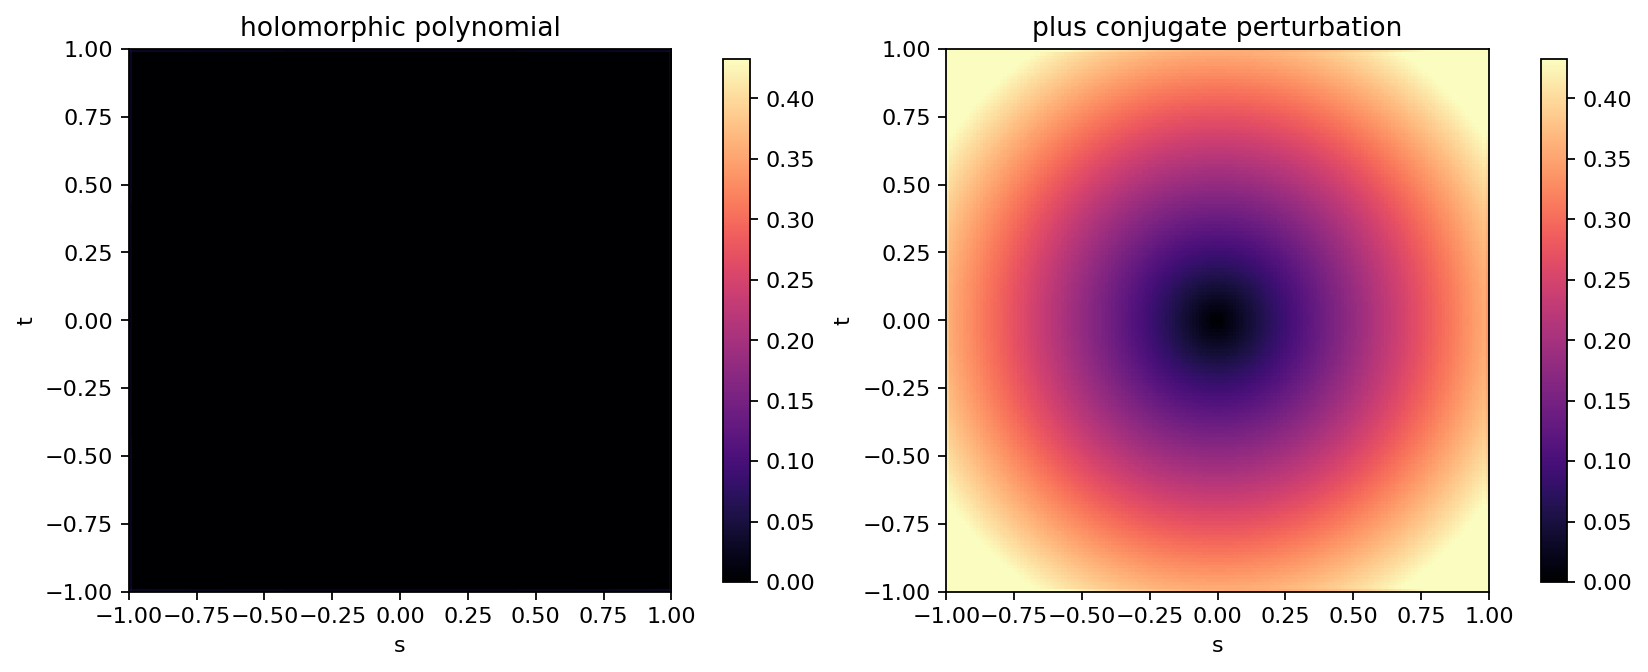

{'conjugate_strength': 0.18,
 'holomorphic_mean_residual': 0.0001562500000000114,
 'perturbed_mean_residual': 0.2599708600974125,
 'residual_ratio': 1663.8135046233187,
 'holomorphic_energy': 16.39472138046635,
 'holomorphic_area': 16.39472120650852,
 'energy_area_relative_error': 1.0610600039087164e-08,
 'passed': True}

In [3]:
n = 161
x = np.linspace(-1.0, 1.0, n)
y = np.linspace(-1.0, 1.0, n)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
conjugate_strength = 0.18
holomorphic = Z**3 - 0.4 * Z
perturbed = holomorphic + conjugate_strength * np.conj(Z) ** 2


def dbar_residual(U):
    Uy, Ux = np.gradient(U, y, x)
    return 0.5 * (Ux + 1j * Uy)


def energy_and_area(U):
    Uy, Ux = np.gradient(U, y, x)
    energy_density = 0.5 * (np.abs(Ux)**2 + np.abs(Uy)**2)
    jacobian = Ux.real * Uy.imag - Uy.real * Ux.imag
    inner = np.s_[5:-5, 5:-5]
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])
    return float(energy_density[inner].sum() * dx * dy), float(jacobian[inner].sum() * dx * dy)

res_h = np.abs(dbar_residual(holomorphic))
res_p = np.abs(dbar_residual(perturbed))
inner = np.s_[5:-5, 5:-5]
energy_h, area_h = energy_and_area(holomorphic)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3), constrained_layout=True)
vmax = float(np.percentile(res_p[inner], 98))
for ax, data, title in zip(axes, [res_h, res_p], ["holomorphic polynomial", "plus conjugate perturbation"]):
    im = ax.imshow(data, extent=[-1, 1, -1, 1], origin="lower", cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("s")
    ax.set_ylabel("t")
    fig.colorbar(im, ax=ax, shrink=0.82)

residual_fig = save_matplotlib(fig, UNIT, "figures", "cauchy-riemann-residual-heatmap.png")
plt.close(fig)

h_mean = float(res_h[inner].mean())
p_mean = float(res_p[inner].mean())
energy_area_relative_error = abs(energy_h - area_h) / max(abs(area_h), 1e-12)
residual_check = {
    "conjugate_strength": conjugate_strength,
    "holomorphic_mean_residual": h_mean,
    "perturbed_mean_residual": p_mean,
    "residual_ratio": float(p_mean / max(h_mean, 1e-12)),
    "holomorphic_energy": energy_h,
    "holomorphic_area": area_h,
    "energy_area_relative_error": float(energy_area_relative_error),
    "passed": bool(p_mean > 100 * h_mean and energy_area_relative_error < 5e-3),
}
residual_json = save_json(residual_check, UNIT, "checks", "cauchy-riemann-residual-checks.json")
display_artifact(residual_fig, width=840)
residual_check


## Unique Continuation: Finite Orders Before Infinite Order

The theorem in the source is analytic, not a finite-grid statement: two solutions that agree to infinite order at one point agree everywhere on the connected domain. The plot below is only a scaffold for the phrase "order of contact." A holomorphic model `z^m` has a straight log-log profile with slope `m`; no finite nonzero `m` should be confused with infinite-order vanishing.

The Carleman similarity principle says that, after a local change of frame, the relevant linear first-order system behaves like a holomorphic equation. That is the bridge from the finite-order picture to the rigidity theorem.


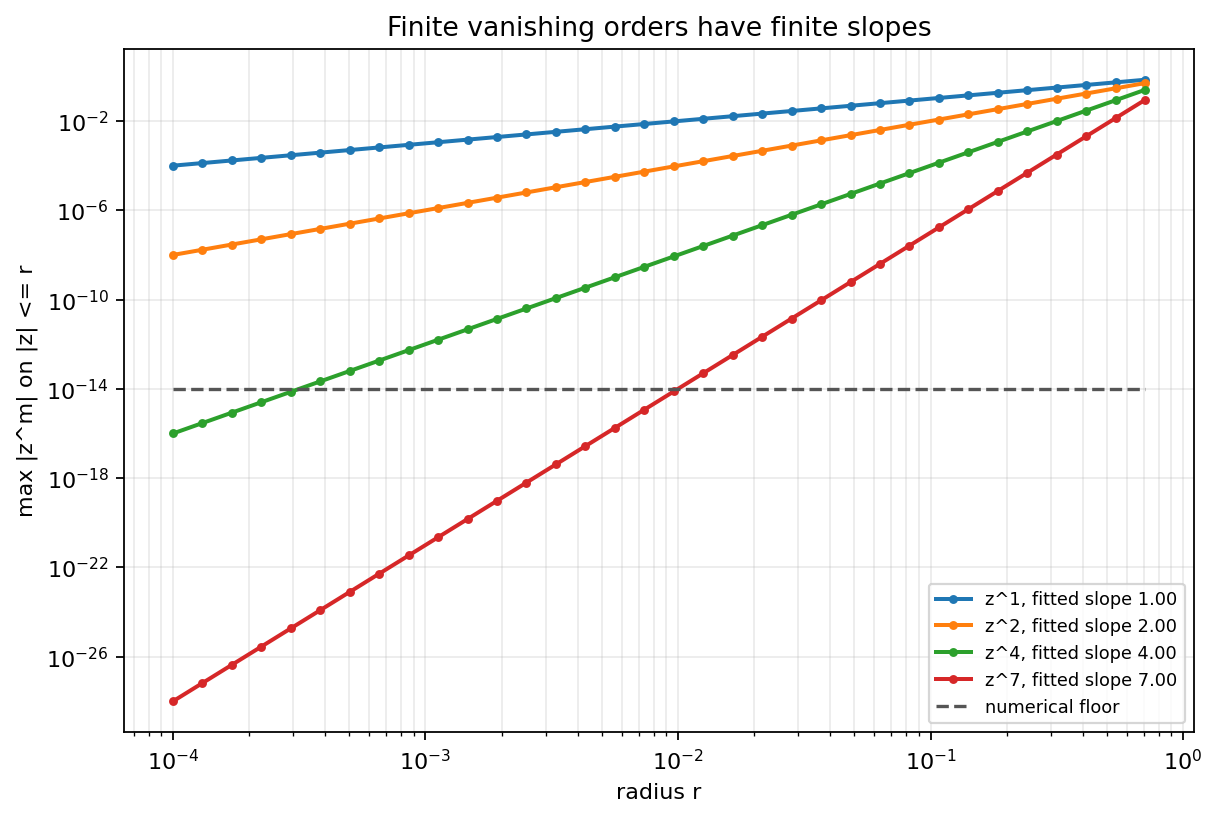

{'orders': [1, 2, 4, 7],
 'fitted_slopes': {'1': 0.9999999999999997,
  '2': 1.9999999999999993,
  '4': 3.9999999999999987,
  '7': 6.999999999999996},
 'max_slope_error': 4.440892098500626e-15,
 'interpretation': 'finite-order holomorphic contacts are visible as finite log-log slopes; infinite-order contact is the analytic rigidity case',
 'passed': True}

In [4]:
radii = np.logspace(-4, -0.15, 34)
orders = [1, 2, 4, 7]
profiles = {m: radii**m for m in orders}
fitted = {}

fig, ax = plt.subplots(figsize=(7.5, 5.0), constrained_layout=True)
for m, values in profiles.items():
    coeffs = np.polyfit(np.log(radii), np.log(values), 1)
    fitted[m] = float(coeffs[0])
    ax.loglog(radii, values, marker="o", markersize=3, linewidth=1.8, label=f"z^{m}, fitted slope {coeffs[0]:.2f}")
ax.loglog(radii, np.full_like(radii, 1e-14), color="#555555", linestyle="--", label="numerical floor")
ax.set_xlabel("radius r")
ax.set_ylabel("max |z^m| on |z| <= r")
ax.set_title("Finite vanishing orders have finite slopes")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)

unique_fig = save_matplotlib(fig, UNIT, "figures", "vanishing-order-tracker.png")
plt.close(fig)

slope_errors = {str(m): abs(fitted[m] - m) for m in orders}
unique_check = {
    "orders": orders,
    "fitted_slopes": {str(m): fitted[m] for m in orders},
    "max_slope_error": float(max(slope_errors.values())),
    "interpretation": "finite-order holomorphic contacts are visible as finite log-log slopes; infinite-order contact is the analytic rigidity case",
    "passed": bool(max(slope_errors.values()) < 1e-10),
}
unique_json = save_json(unique_check, UNIT, "checks", "unique-continuation-order-checks.json")
display_artifact(unique_fig, width=760)
unique_check


## Critical Points, Somewhere Injective Curves, and Multiple Covers

The model `z -> z^2` compresses several Chapter 2 ideas into one local picture. Its derivative vanishes only at the branch point, so the critical point is isolated. Away from the branch point, a generic target value has two preimages, so the map is a multiple cover of the target coordinate. By contrast, the graph map `z -> (z,z^2)` is injective because its first coordinate remembers the parameter.

This is the computational translation of the simple-versus-covered distinction. Simple curves are the ones for which injective points remain after removing critical and repeated-image points; multiple covers factor through a branched covering of the domain.


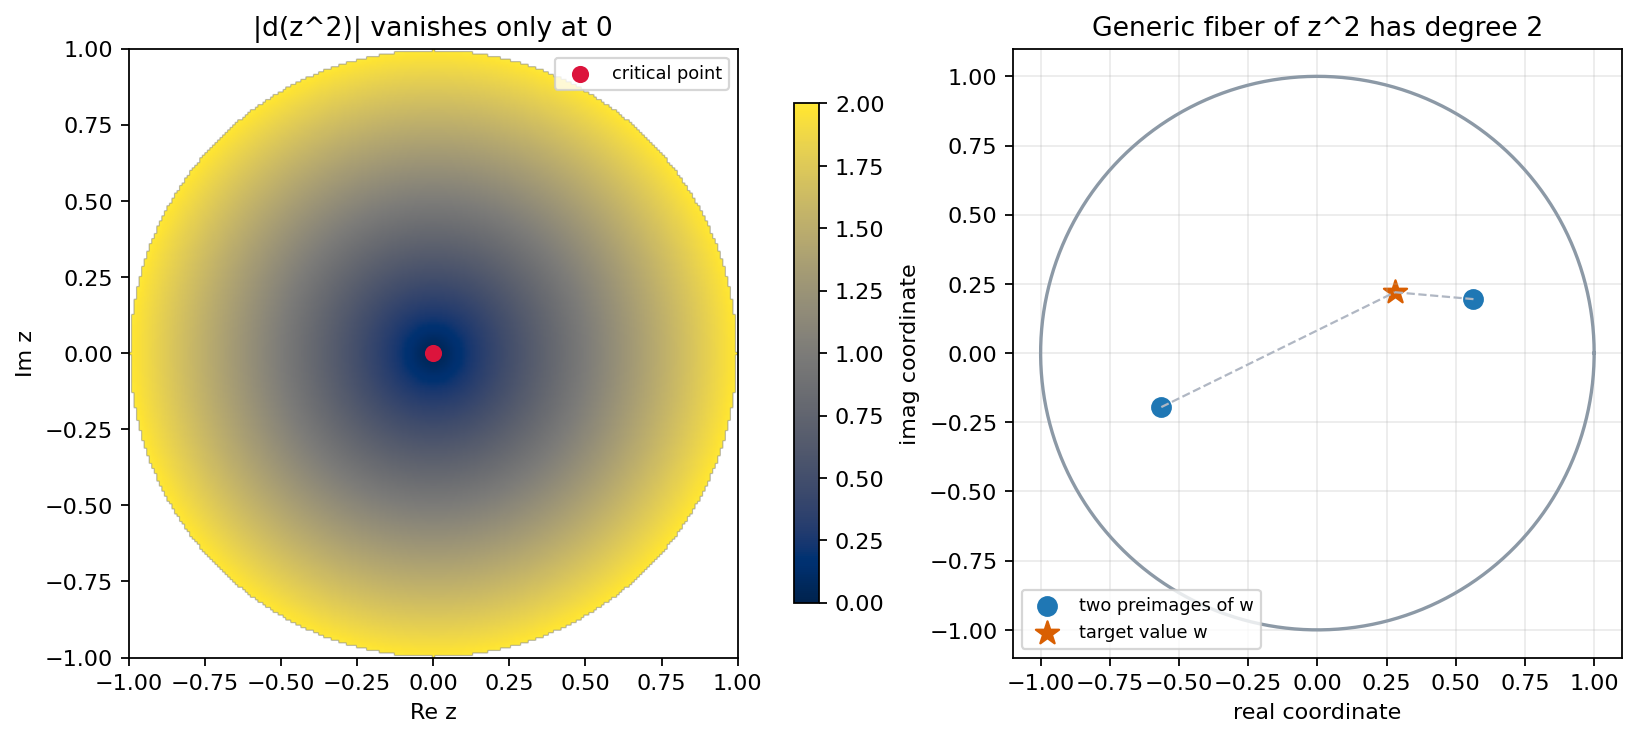

{'model': 'z -> z^2 and graph z -> (z,z^2)',
 'critical_points_exact': ['0'],
 'generic_target': {'real': 0.28, 'imag': 0.22},
 'generic_fiber_count_for_z_squared': 2,
 'root_moduli': [0.5967326673606005, 0.5967326673606005],
 'simple_graph_first_coordinates_unique': True,
 'multiple_cover_pair_has_same_factored_value': True,
 'passed': True}

In [5]:
grid = np.linspace(-1.0, 1.0, 241)
GX, GY = np.meshgrid(grid, grid)
GZ = GX + 1j * GY
mask = np.abs(GZ) <= 1.0
derivative_norm = np.ma.masked_where(~mask, 2.0 * np.abs(GZ))
w0 = 0.28 + 0.22j
root = np.sqrt(w0)
roots = np.array([root, -root])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.5), constrained_layout=True)
ax = axes[0]
im = ax.imshow(derivative_norm, extent=[-1, 1, -1, 1], origin="lower", cmap="cividis")
ax.scatter([0], [0], color="crimson", s=45, label="critical point")
ax.set_title("|d(z^2)| vanishes only at 0")
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, shrink=0.82)
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
unit_circle = np.exp(1j * np.linspace(0, 2*np.pi, 400))
ax.plot(unit_circle.real, unit_circle.imag, color="#8c99a6")
ax.scatter(roots.real, roots.imag, color="#1f77b4", s=70, label="two preimages of w")
ax.scatter([w0.real], [w0.imag], color="#d95f02", marker="*", s=120, label="target value w")
for z in roots:
    ax.plot([z.real, w0.real], [z.imag, w0.imag], color="#b0b7c3", linestyle="--", linewidth=1)
ax.set_title("Generic fiber of z^2 has degree 2")
ax.set_xlabel("real coordinate")
ax.set_ylabel("imag coordinate")
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.legend(loc="lower left", fontsize=8)

cover_fig = save_matplotlib(fig, UNIT, "figures", "critical-points-and-multiple-covers.png")
plt.close(fig)

sample = np.array([0.15 + 0.2j, -0.3 + 0.4j, 0.55 - 0.1j, -0.2 - 0.45j])
simple_graph = [(complex(z), complex(z**2)) for z in sample]
cover_graph = [(complex(z**2), complex(z**4)) for z in np.array([root, -root])]
simple_first_coordinates_unique = len({pair[0] for pair in simple_graph}) == len(simple_graph)
cover_factor_values_match = abs(cover_graph[0][0] - cover_graph[1][0]) < 1e-12 and abs(cover_graph[0][1] - cover_graph[1][1]) < 1e-12

cover_check = {
    "model": "z -> z^2 and graph z -> (z,z^2)",
    "critical_points_exact": ["0"],
    "generic_target": {"real": float(w0.real), "imag": float(w0.imag)},
    "generic_fiber_count_for_z_squared": int(len(roots)),
    "root_moduli": [float(abs(z)) for z in roots],
    "simple_graph_first_coordinates_unique": bool(simple_first_coordinates_unique),
    "multiple_cover_pair_has_same_factored_value": bool(cover_factor_values_match),
    "passed": bool(len(roots) == 2 and all(abs(z) < 1 for z in roots) and simple_first_coordinates_unique and cover_factor_values_match),
}
cover_json = save_json(cover_check, UNIT, "checks", "critical-multiple-cover-checks.json")
display_artifact(cover_fig, width=840)
cover_check


## Proof Visual: From Local Analysis to Curve Structure

The graph keeps the chapter's dependencies explicit. The nonlinear equation supplies the residual and elliptic structure. Carleman similarity and unique continuation feed the local facts about critical points and branch behavior. Those local facts separate simple curves from multiple covers, and in four dimensions positivity of intersections turns local singularity data into adjunction bounds.


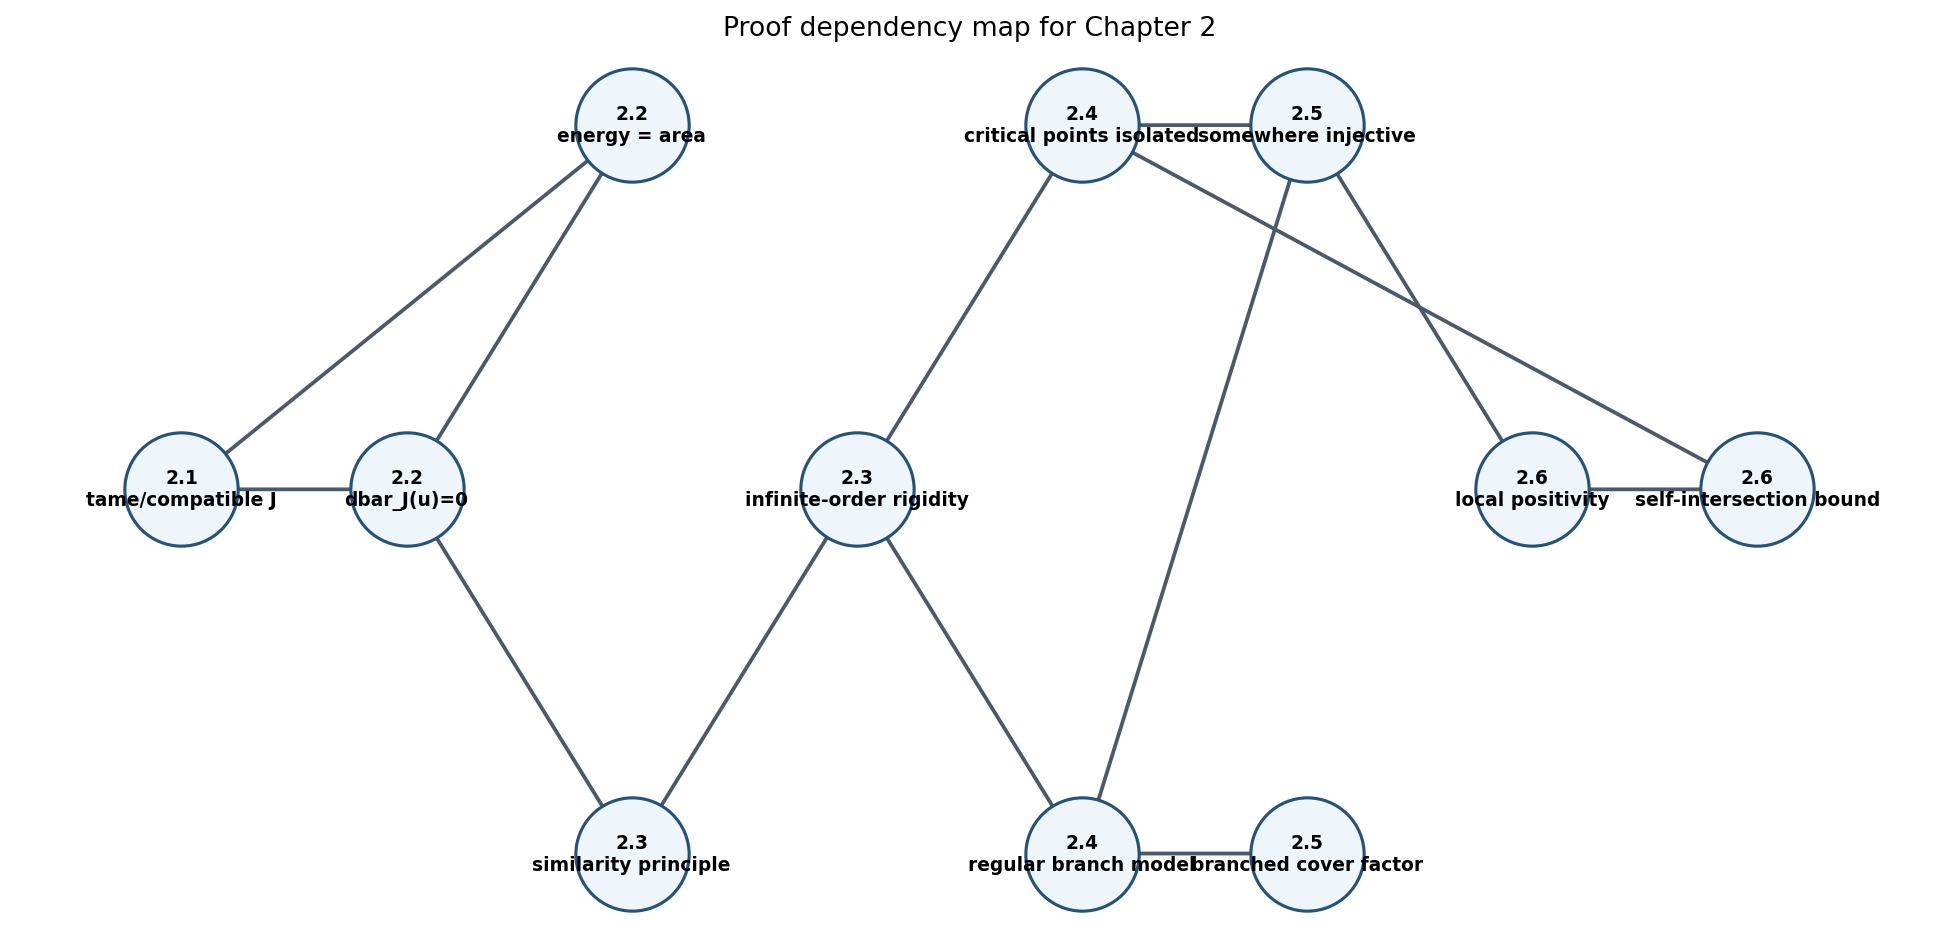

{'nodes': 11,
 'edges': 13,
 'is_directed_acyclic_graph': True,
 'required_terminal_nodes_present': ['adjunction',
  'energy identity',
  'multiple covers'],
 'source_span': 'printed pp. 17-38; PDF pp. 32-53',
 'passed': True}

In [6]:
proof_nodes = {
    "J linear algebra": "2.1\ntame/compatible J",
    "dbar equation": "2.2\ndbar_J(u)=0",
    "energy identity": "2.2\nenergy = area",
    "Carleman frame": "2.3\nsimilarity principle",
    "unique continuation": "2.3\ninfinite-order rigidity",
    "critical isolation": "2.4\ncritical points isolated",
    "local branch factorization": "2.4\nregular branch model",
    "simple curves": "2.5\nsomewhere injective",
    "multiple covers": "2.5\nbranched cover factor",
    "positive intersections": "2.6\nlocal positivity",
    "adjunction": "2.6\nself-intersection bound",
}
proof_edges = [
    ("J linear algebra", "dbar equation"),
    ("J linear algebra", "energy identity"),
    ("dbar equation", "energy identity"),
    ("dbar equation", "Carleman frame"),
    ("Carleman frame", "unique continuation"),
    ("unique continuation", "critical isolation"),
    ("unique continuation", "local branch factorization"),
    ("critical isolation", "simple curves"),
    ("local branch factorization", "simple curves"),
    ("local branch factorization", "multiple covers"),
    ("simple curves", "positive intersections"),
    ("critical isolation", "adjunction"),
    ("positive intersections", "adjunction"),
]
G = nx.DiGraph()
G.add_nodes_from(proof_nodes)
G.add_edges_from(proof_edges)
layer = {
    "J linear algebra": 0,
    "dbar equation": 1,
    "energy identity": 2,
    "Carleman frame": 2,
    "unique continuation": 3,
    "critical isolation": 4,
    "local branch factorization": 4,
    "simple curves": 5,
    "multiple covers": 5,
    "positive intersections": 6,
    "adjunction": 7,
}
pos = {}
for node, x_layer in layer.items():
    siblings = [n for n, l in layer.items() if l == x_layer]
    idx = siblings.index(node)
    offset = (idx - (len(siblings)-1)/2) * 1.25
    pos[node] = (x_layer, -offset)

fig, ax = plt.subplots(figsize=(12.0, 5.8), constrained_layout=True)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=17, width=1.7, edge_color="#4b5968")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600, node_color="#eef5fb", edgecolors="#24527a", linewidths=1.4)
nx.draw_networkx_labels(G, pos, labels=proof_nodes, ax=ax, font_size=8.4, font_weight="bold")
ax.set_title("Proof dependency map for Chapter 2")
ax.set_axis_off()
proof_fig = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

required_terminals = {"multiple covers", "adjunction", "energy identity"}
proof_check = {
    "nodes": len(proof_nodes),
    "edges": len(proof_edges),
    "is_directed_acyclic_graph": bool(nx.is_directed_acyclic_graph(G)),
    "required_terminal_nodes_present": sorted(required_terminals),
    "source_span": "printed pp. 17-38; PDF pp. 32-53",
    "passed": bool(nx.is_directed_acyclic_graph(G) and required_terminals.issubset(G.nodes)),
}
proof_json = save_json(proof_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(proof_fig, width=900)
proof_check


## Adjunction Ledger in CP2

In an almost complex four-manifold, positivity of intersections gives numerical control over intersections and singularities. For a connected degree `d` curve in `CP2`, the adjunction inequality becomes

`delta + g <= (d - 1)(d - 2) / 2`.

The right side is the arithmetic genus bound. A smooth curve spends the allowance on genus; a nodal rational curve spends it on double points. The integer examples below are not a proof of adjunction, but they make the accounting visible.


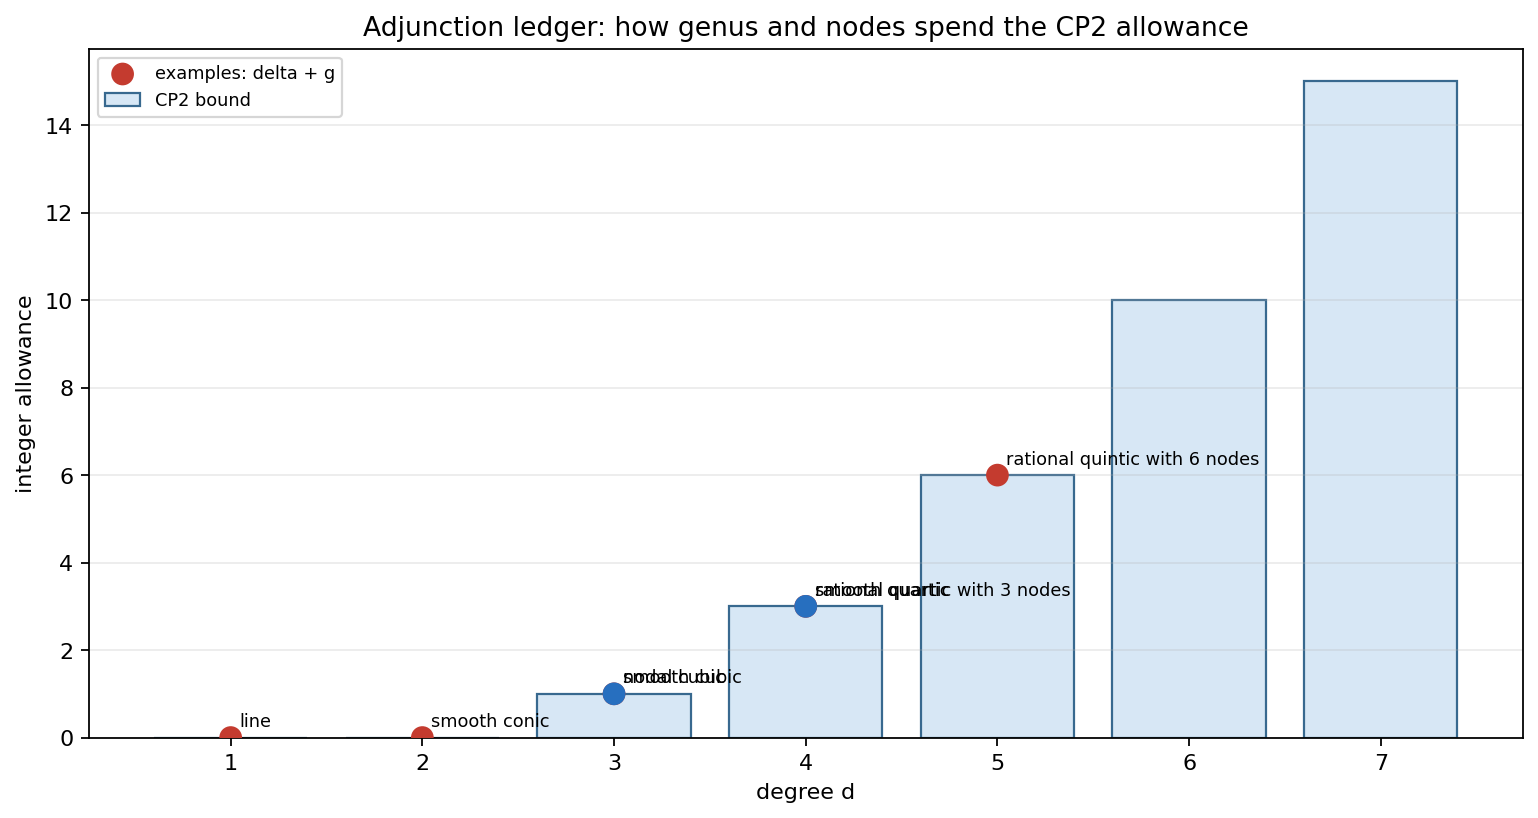

{'examples': [{'name': 'line',
   'd': 1,
   'g': 0,
   'delta': 0,
   'bound': 0,
   'delta_plus_g': 0,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'smooth conic',
   'd': 2,
   'g': 0,
   'delta': 0,
   'bound': 0,
   'delta_plus_g': 0,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'nodal cubic',
   'd': 3,
   'g': 0,
   'delta': 1,
   'bound': 1,
   'delta_plus_g': 1,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'smooth cubic',
   'd': 3,
   'g': 1,
   'delta': 0,
   'bound': 1,
   'delta_plus_g': 1,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'rational quartic with 3 nodes',
   'd': 4,
   'g': 0,
   'delta': 3,
   'bound': 3,
   'delta_plus_g': 3,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'smooth quartic',
   'd': 4,
   'g': 3,
   'delta': 0,
   'bound': 3,
   'delta_plus_g': 3,
   'adjunction_defect': 0,
   'bound_defect': 0},
  {'name': 'rational quintic with 6 nodes',
   'd': 5,
   'g': 0,
   'de

In [7]:
def cp2_bound(d):
    return (d - 1) * (d - 2) // 2

examples = [
    {"name": "line", "d": 1, "g": 0, "delta": 0},
    {"name": "smooth conic", "d": 2, "g": 0, "delta": 0},
    {"name": "nodal cubic", "d": 3, "g": 0, "delta": 1},
    {"name": "smooth cubic", "d": 3, "g": 1, "delta": 0},
    {"name": "rational quartic with 3 nodes", "d": 4, "g": 0, "delta": 3},
    {"name": "smooth quartic", "d": 4, "g": 3, "delta": 0},
    {"name": "rational quintic with 6 nodes", "d": 5, "g": 0, "delta": 6},
]
for row in examples:
    d = row["d"]
    bound = cp2_bound(d)
    chi = 2 - 2 * row["g"]
    lhs = 2 * row["delta"] - chi
    rhs = d * d - 3 * d
    row["bound"] = int(bound)
    row["delta_plus_g"] = int(row["delta"] + row["g"])
    row["adjunction_defect"] = int(rhs - lhs)
    row["bound_defect"] = int(bound - row["delta_plus_g"])

degrees = np.arange(1, 8)
bounds = np.array([cp2_bound(int(d)) for d in degrees])

fig, ax = plt.subplots(figsize=(9.5, 5.0), constrained_layout=True)
ax.bar(degrees, bounds, color="#d7e7f5", edgecolor="#38698f", label="CP2 bound")
colors = ["#276fbf" if row["g"] > 0 else "#c43b2f" for row in examples]
ax.scatter([row["d"] for row in examples], [row["delta_plus_g"] for row in examples], s=85, color=colors, zorder=3, label="examples: delta + g")
for row in examples:
    ax.annotate(row["name"], (row["d"], row["delta_plus_g"]), xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("degree d")
ax.set_ylabel("integer allowance")
ax.set_title("Adjunction ledger: how genus and nodes spend the CP2 allowance")
ax.set_xticks(degrees)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", fontsize=8)
adjunction_fig = save_matplotlib(fig, UNIT, "figures", "adjunction-defect-ledger.png")
plt.close(fig)

adjunction_check = {
    "examples": examples,
    "all_bound_defects_nonnegative": bool(all(row["bound_defect"] >= 0 for row in examples)),
    "all_adjunction_defects_nonnegative": bool(all(row["adjunction_defect"] >= 0 for row in examples)),
    "equality_examples": [row["name"] for row in examples if row["bound_defect"] == 0],
    "passed": bool(all(row["bound_defect"] >= 0 for row in examples) and all(row["adjunction_defect"] >= 0 for row in examples)),
}
adjunction_json = save_json(adjunction_check, UNIT, "checks", "adjunction-ledger-checks.json")
display_artifact(adjunction_fig, width=820)
adjunction_check


## Invariant Ledger

The ledger records the chapter concepts as computational objects. Each row names the inspection target and the JSON check that protects it. This is intentionally small: the goal is not to simulate the full analytic theory, but to make every visual accountable to a local invariant or a finite model of the theorem's bookkeeping.


In [8]:
ledger_rows = [
    {"item": "almost complex structure", "computational_object": "matrix family J_a and metric omega(.,J_a .)", "artifact": "almost-complex-taming-metric.png", "check": "almost-complex-structure-checks.json"},
    {"item": "nonlinear Cauchy-Riemann residual", "computational_object": "finite-difference dbar field", "artifact": "cauchy-riemann-residual-heatmap.png", "check": "cauchy-riemann-residual-checks.json"},
    {"item": "unique continuation", "computational_object": "finite vanishing-order slopes for z^m", "artifact": "vanishing-order-tracker.png", "check": "unique-continuation-order-checks.json"},
    {"item": "critical point", "computational_object": "branch derivative |d(z^2)|", "artifact": "critical-points-and-multiple-covers.png", "check": "critical-multiple-cover-checks.json"},
    {"item": "somewhere injective versus multiple cover", "computational_object": "graph map z -> (z,z^2) compared with z -> z^2", "artifact": "critical-points-and-multiple-covers.png", "check": "critical-multiple-cover-checks.json"},
    {"item": "adjunction inequality", "computational_object": "CP2 degree, genus, and double-point rows", "artifact": "adjunction-defect-ledger.png", "check": "adjunction-ledger-checks.json"},
    {"item": "proof dependencies", "computational_object": "directed acyclic graph of chapter implications", "artifact": "proof-dependency-map.png", "check": "proof-dependency-map.json"},
]

table_path = TABLE_DIR / "invariant-ledger.csv"
with table_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=["item", "computational_object", "artifact", "check"])
    writer.writeheader()
    writer.writerows(ledger_rows)

ledger_check = {
    "row_count": len(ledger_rows),
    "items": [row["item"] for row in ledger_rows],
    "artifacts": sorted({row["artifact"] for row in ledger_rows}),
    "checks": sorted({row["check"] for row in ledger_rows}),
    "has_source_specific_checks": bool(all(row["check"].endswith(".json") for row in ledger_rows)),
    "passed": bool(len(ledger_rows) >= 6 and all(row["artifact"] and row["check"] for row in ledger_rows)),
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
display_artifact(table_path)
ledger_check


{'row_count': 7,
 'items': ['almost complex structure',
  'nonlinear Cauchy-Riemann residual',
  'unique continuation',
  'critical point',
  'somewhere injective versus multiple cover',
  'adjunction inequality',
  'proof dependencies'],
 'artifacts': ['adjunction-defect-ledger.png',
  'almost-complex-taming-metric.png',
  'cauchy-riemann-residual-heatmap.png',
  'critical-points-and-multiple-covers.png',
  'proof-dependency-map.png',
  'vanishing-order-tracker.png'],
 'checks': ['adjunction-ledger-checks.json',
  'almost-complex-structure-checks.json',
  'cauchy-riemann-residual-checks.json',
  'critical-multiple-cover-checks.json',
  'proof-dependency-map.json',
  'unique-continuation-order-checks.json'],
 'has_source_specific_checks': True,
 'passed': True}

## Applied Lab

Change exactly one of these parameters and rerun the notebook:

- `a_value` in the almost-complex cell. The symbolic identity `J_a^2=-I` should survive, while the metric ellipse and taming heatmap change shape.
- `conjugate_strength` in the residual cell. The perturbed residual should scale with that coefficient, while the holomorphic energy-area check should be unchanged.
- `w0` in the multiple-cover cell. As long as `w0` stays inside the unit disk and away from zero, the fiber of `z^2` should still have two preimages.
- one row in the adjunction examples. A row with `delta + g` above the CP2 bound should fail the final checks.

The intended habit is to compare three things after any edit: the visual inspection target, the corresponding JSON values, and the final sanity cell. If they disagree, the JSON check is the first place to debug.


## Takeaways

- A tame or compatible almost complex structure is pointwise linear algebra, but it creates the metric and residual used throughout the analytic theory.
- The local Cauchy-Riemann residual is a practical diagnostic: holomorphic terms are dark in the heatmap, anti-holomorphic terms light up.
- Unique continuation is stronger than finite-order contact. The finite-order plot is a scaffold for why infinite-order agreement is exceptional.
- Critical points and repeated images are controlled enough that simple curves have injective points; multiple covers are separated by a branched covering.
- In real dimension four, positivity of intersections turns local singularities and double points into the adjunction inequality.


## Sanity Checks

The final cell asserts the generated figures, tables, and JSON summaries; then it writes `final-sanity.json`. The checks are deliberately redundant so a stale path or a decorative visual without an invariant fails loudly.


In [9]:
assert_artifact(FIG_DIR / "almost-complex-taming-metric.png", min_bytes=512)
assert_artifact(FIG_DIR / "cauchy-riemann-residual-heatmap.png", min_bytes=512)
assert_artifact(FIG_DIR / "vanishing-order-tracker.png", min_bytes=512)
assert_artifact(FIG_DIR / "critical-points-and-multiple-covers.png", min_bytes=512)
assert_artifact(FIG_DIR / "proof-dependency-map.png", min_bytes=512)
assert_artifact(FIG_DIR / "adjunction-defect-ledger.png", min_bytes=512)
assert_artifact(TABLE_DIR / "invariant-ledger.csv", min_bytes=80)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=80)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=80)
assert_artifact(CHECK_DIR / "almost-complex-structure-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "cauchy-riemann-residual-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "unique-continuation-order-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "critical-multiple-cover-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "proof-dependency-map.json", min_bytes=80)
assert_artifact(CHECK_DIR / "adjunction-ledger-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "invariant-ledger.json", min_bytes=80)

check_paths = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "almost-complex-structure-checks.json",
    CHECK_DIR / "cauchy-riemann-residual-checks.json",
    CHECK_DIR / "unique-continuation-order-checks.json",
    CHECK_DIR / "critical-multiple-cover-checks.json",
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / "adjunction-ledger-checks.json",
    CHECK_DIR / "invariant-ledger.json",
]
loaded_checks = {path.name: json.loads(path.read_text(encoding="utf-8")) for path in check_paths}
assert all(data.get("passed") is True for data in loaded_checks.values())
assert loaded_checks["almost-complex-structure-checks.json"]["minimum_taming_on_unit_circle"] > 0
assert loaded_checks["cauchy-riemann-residual-checks.json"]["residual_ratio"] > 100
assert loaded_checks["cauchy-riemann-residual-checks.json"]["energy_area_relative_error"] < 5e-3
assert loaded_checks["critical-multiple-cover-checks.json"]["generic_fiber_count_for_z_squared"] == 2
assert loaded_checks["adjunction-ledger-checks.json"]["all_bound_defects_nonnegative"] is True

final_sanity = {
    "unit": UNIT,
    "source_span": "printed pp. 17-38; PDF pp. 32-53",
    "artifact_count": 17,
    "figure_count": 6,
    "check_count": len(check_paths),
    "checks": sorted(loaded_checks),
    "standalone_markers": ["Source Coverage", "Library Routing", "Visualization Storyboard", "Applied Lab", "Takeaways"],
    "core_validations": {
        "taming_positive": loaded_checks["almost-complex-structure-checks.json"]["minimum_taming_on_unit_circle"] > 0,
        "residual_ratio_gt_100": loaded_checks["cauchy-riemann-residual-checks.json"]["residual_ratio"] > 100,
        "unique_order_slopes": loaded_checks["unique-continuation-order-checks.json"]["max_slope_error"] < 1e-10,
        "cover_degree_two": loaded_checks["critical-multiple-cover-checks.json"]["generic_fiber_count_for_z_squared"] == 2,
        "adjunction_defects_nonnegative": loaded_checks["adjunction-ledger-checks.json"]["all_adjunction_defects_nonnegative"] is True,
    },
    "final_sanity": True,
    "passed": True,
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=80)
print(f"Validated {final_sanity['artifact_count']} artifacts/check records for {UNIT}")


Validated 17 artifacts/check records for chapter-02
